In [ ]:
import pandas as pd
data=pd.read_csv('/content/Telco_Cusomer_Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.shape

(7043, 21)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


***Selecting Columns To Analyse***

1.   Churn
2.   Tenure
3.   PaymentMethod
4.   MonthlyCharges
5.   Contract






In [ ]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
data.isnull().sum()/len(data)*100

,0
customerID,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


In [ ]:
data['Churn'].value_counts()/len(data['Churn'])*100

,count
Churn,
No,73.463013
Yes,26.536987


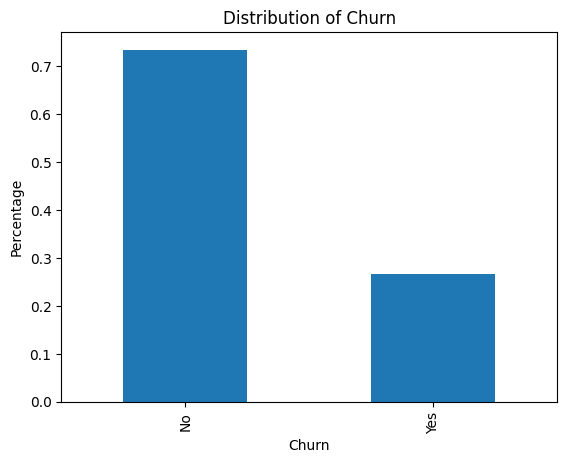

In [ ]:
from matplotlib.cbook import normalize_kwargs
import seaborn as sns
import matplotlib.pyplot as plt
data['Churn'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Percentage')
plt.show()

**Identified moderate class imbalance (73:27) in churn data and selected appropriate evaluation metrics and imbalance-handling strategies.**

1.   Consider using SMOTE




In [ ]:
data.duplicated().any()

np.False_

In [ ]:
data['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

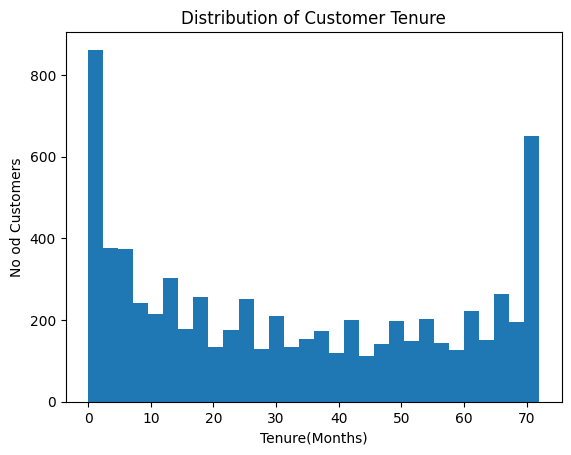

In [ ]:
plt.hist(data['tenure'],bins=30)
plt.xlabel('Tenure(Months)')
plt.ylabel('No od Customers')
plt.title('Distribution of Customer Tenure')
plt.show()

**Tenure Insight**


*   Large number of Customers Leave Very Early
*   First Few Months are crucial for customer retention

**The tenure distribution is right-skewed with a strong concentration of customers in the initial months and at maximum tenure. This indicates early churn risk and highlights tenure as a strong predictive feature for churn modeling.**

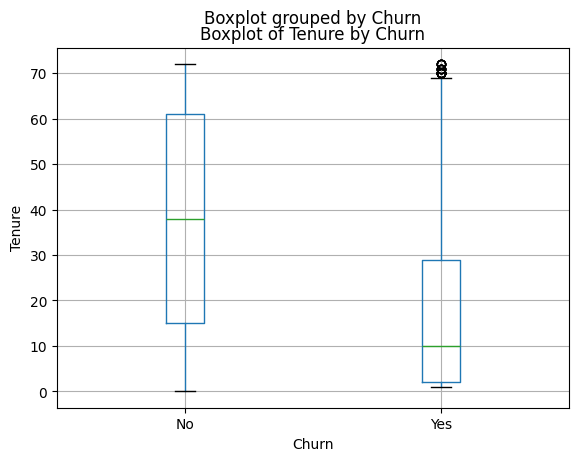

In [ ]:
data.boxplot(column='tenure',by='Churn')
plt.title('Boxplot of Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()


In [ ]:
data['Churn']=data['Churn'].map({'No':0,'Yes':1})

In [ ]:
data['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
corr=data[['tenure','Churn']].corr()
corr

,tenure,Churn
tenure,1.000000,-0.352229
Churn,-0.352229,1.000000


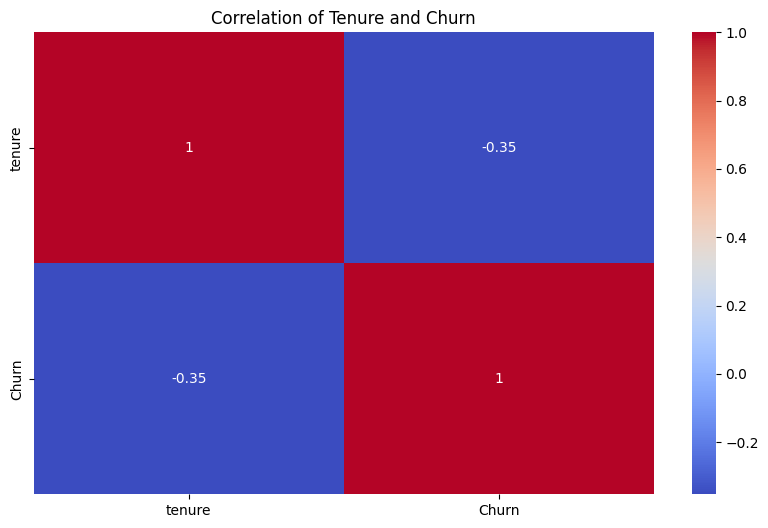

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation of Tenure and Churn')
plt.show()

**The correlation heatmap shows a moderate negative correlation (−0.35) between tenure and churn, indicating that customers with longer tenure are less likely to churn**

In [ ]:
data['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


**Checking if Payment Method Effects Churn**

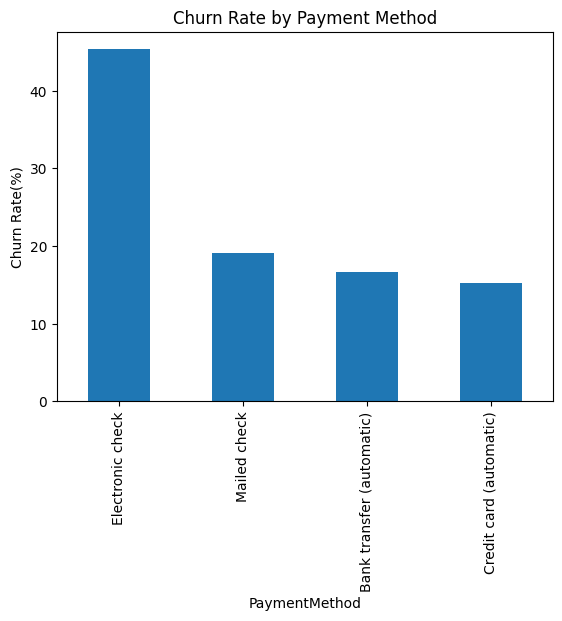

In [ ]:
churn_rate_by_payment_method=data.groupby('PaymentMethod')['Churn'].mean() * 100
churn_rate_by_payment_method.sort_values(ascending=False).plot(kind='bar')
plt.ylabel('Churn Rate(%)')
plt.title('Churn Rate by Payment Method')
plt.show()

**Electronic check users show the highest churn rate(45%). This suggests that payment method may be associated with customer churn**

In [ ]:
data['MonthlyCharges'].describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

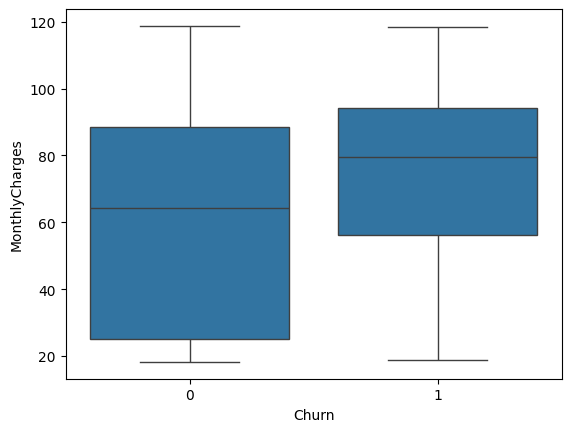

In [ ]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=data)

**Higher monthly charges are associated with higher churn.**

**Revenue Loss Analysis**

> Revenue analysis on Churned vs Not Churned



In [ ]:
churned_revenue=data[data['Churn']==1]['MonthlyCharges'].sum()
retained_revenue=data[data['Churn']==0]['MonthlyCharges'].sum()
print(f"Churned Revenue: ${churned_revenue:,.2f}")
print(f"Retained Revenue: ${retained_revenue:,.2f}")

Churned Revenue: $139,130.85
Retained Revenue: $316,985.75


**High Risk Customers**

In [ ]:
data['High_Risk_Customers']=((data['Churn']==1) & (data['MonthlyCharges']>data['MonthlyCharges'].median()))

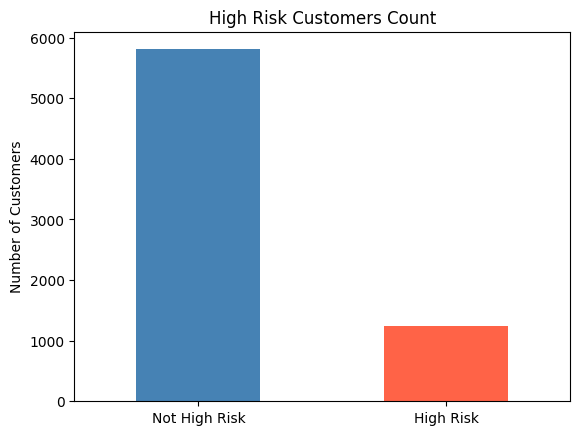

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data['High_Risk_Customers'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'tomato']
)

plt.xticks([0, 1], ['Not High Risk', 'High Risk'], rotation=0)
plt.title('High Risk Customers Count')
plt.ylabel('Number of Customers')
plt.xlabel('')
plt.show()

In [ ]:
data['High_Risk_Customers'].value_counts()

,count
High_Risk_Customers,
False,5806
True,1237


**There are 1,237 Customers with High Risk**

/tmp/ipython-input-1948004310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


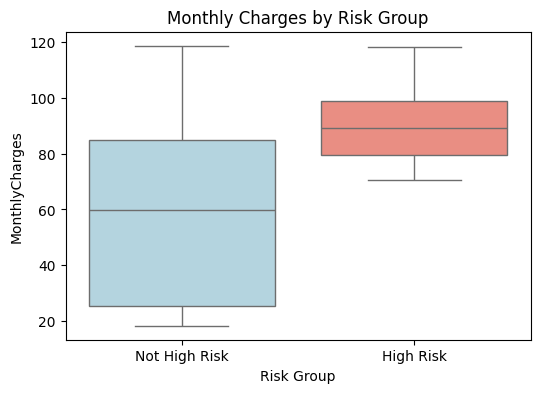

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='High_Risk_Customers',
    y='MonthlyCharges',
    data=data,
    palette=['lightblue', 'salmon']
)

plt.xticks([0,1], ['Not High Risk', 'High Risk'])
plt.title('Monthly Charges by Risk Group')
plt.xlabel('Risk Group')
plt.show()

**High Risk is Associated with Higher Monthly Prices**

In [ ]:
data['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


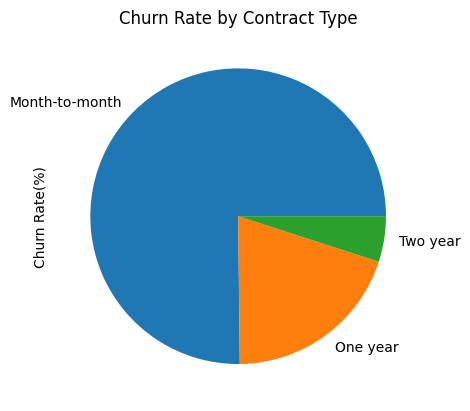

In [ ]:
churn_rate_by_contract=data.groupby('Contract')['Churn'].mean() * 100
churn_rate_by_contract.sort_values(ascending=False).plot(kind='pie')
plt.ylabel('Churn Rate(%)')
plt.title('Churn Rate by Contract Type')
plt.show()

**Month-to-month has Higher Churn Rate(%) While Two year and One year Contract Type has less Churn Rate**


# Revenue Analysis

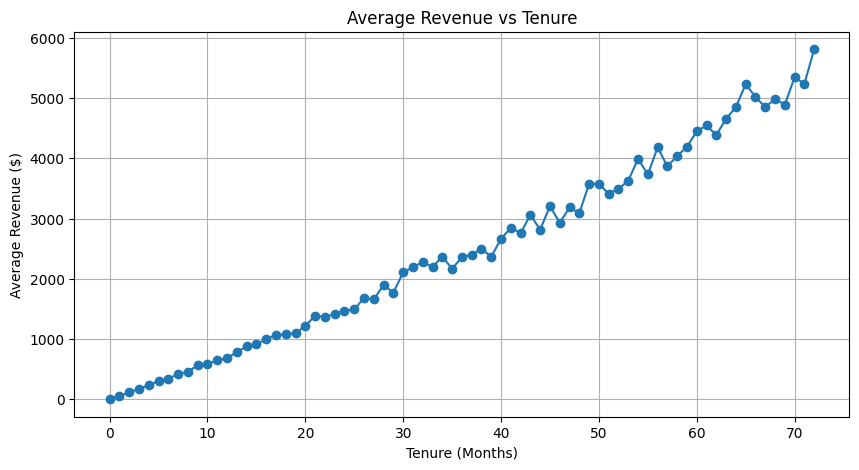

In [ ]:
data['revenue']=data['MonthlyCharges'] * data['tenure']
revenue_by_tenure = data.groupby('tenure')['revenue'].mean()
plt.figure(figsize=(10,5))
plt.plot(revenue_by_tenure.index, revenue_by_tenure.values, marker='o')
plt.title('Average Revenue vs Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Average Revenue ($)')
plt.grid(True)
plt.show()

In [ ]:
corr1=data[['revenue','tenure']].corr()
corr1

,revenue,tenure
revenue,1.000000,0.826568
tenure,0.826568,1.000000


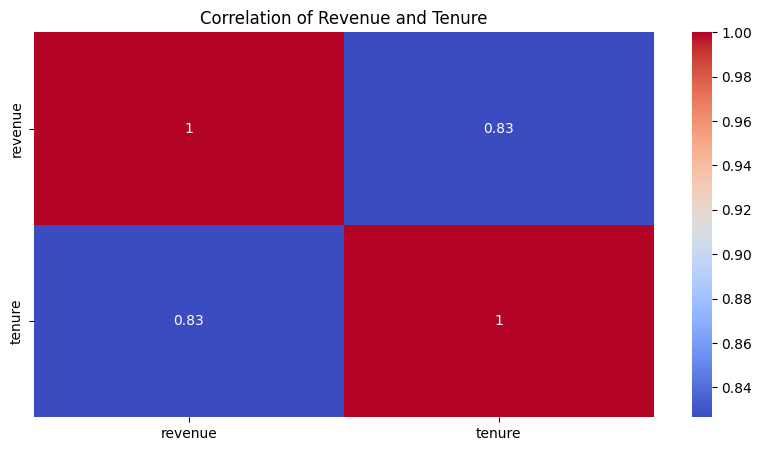

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(corr1,annot=True,cmap='coolwarm')
plt.title('Correlation of Revenue and Tenure')
plt.show()

**Revenue Increases as Tenure Increases**

# Key Insights From EDA
*   Large number of Customers Leave Very Early
*   First Few Months are crucial for customer retention
*   Tenure Predictability is High(Consider Using SMOTE)
*   Customers With Longer Tenure are Less Likely to Churn
*   Electronic check users show the highest churn rate(45%). This suggests  
that payment method may be associated with customer churn  
*   According to MonthlyCharges vs Churn, Higher monthly charges are associated with higher churn.
*   On Performing Revenue Analysis of Churned Customers ,Total Revenue Lost by Churned Customers is $139,130
*   There are 1,237 Customers with High Risk of Churning
*   On Performing High Risk Customers vs Monthly Charges,High Risk is Associated with Higher Monthly Prices
*   Month-to-month has Higher Churn Rate(%) While Two year and One year Contract Type has less Churn Rate
*   Revenue Increase is directly Proportional to Tenure



# Model building

In [ ]:
categorical_cols = data.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object')


In [ ]:
df_encoded=pd.get_dummies(data,columns=categorical_cols,drop_first=True)

In [ ]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,High_Risk_Customers,revenue,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,False,29.85,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,0,False,1936.30,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,1,False,107.70,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,0,False,1903.50,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,1,True,141.40,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
data_processed = data.copy()

# 1. Handle 'TotalCharges': Convert to numeric, coerce errors to NaN, then drop NaNs
data_processed['TotalCharges'] = pd.to_numeric(data_processed['TotalCharges'], errors='coerce')
data_processed.dropna(subset=['TotalCharges'], inplace=True)

# 2. Drop unnecessary columns
data_processed.drop(columns=['customerID', 'High_Risk_Customers', 'revenue'], inplace=True)

# 3. Separate features (X) and target (y)
X = data_processed.drop(columns=['Churn'])
y = data_processed['Churn']

# 4. Identify categorical columns for one-hot encoding
categorical_cols_X = X.select_dtypes(include='object').columns

# 5. Apply One-Hot Encoding to categorical columns in X
X = pd.get_dummies(X, columns=categorical_cols_X, drop_first=True)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.20)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test)
print("Predictions made successfully.")

Predictions made successfully.


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1038
           1       0.56      0.44      0.49       369

    accuracy                           0.76      1407
   macro avg       0.69      0.66      0.67      1407
weighted avg       0.75      0.76      0.75      1407


Accuracy Score:
0.7640369580668088
